# Testing Combined H5 Processing

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


## Single Event Testing

In [2]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

Augmenting particles
Ready with tracker hits Index(['cellID', 'time', 'x', 'y', 'z', 'particle_id', 'detector', 'r', 'R',
       'phi', 'theta', 'eta'],
      dtype='object')
Augmenting particle hit counts with tracker hits


In [4]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v7/runs/0/edm4hep.root"
event2 = EDM4hepEvent(edm_input_file, event_index=0)

In [3]:
print(f"""
Number of calo hits: {len(event.get_calo_hits_df())}
Number of particles: {len(event.get_particles_df())}
Number of tracker hits: {len(event.get_tracker_hits_df())}
""")


Number of calo hits: 1243953
Number of particles: 880327
Number of tracker hits: 240622



In [10]:
print(f"""
Number of calo hits: {len(event2.get_calo_hits_df())}
Number of particles: {len(event2.get_particles_df())}
Number of tracker hits: {len(event2.get_tracker_hits_df())}
""")


Number of calo hits: 1120404
Number of particles: 190319
Number of tracker hits: 217781



In [11]:
event2.get_calo_hits_df()

,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,152559394436048912,3.538352e-04,1190.580322,437.952515,2759.100098,0,9,ECalBarrelCollection,1268.575562,3036.760986,0.352486,0.430956,1.519249
1,4503814384687120,5.628845e-05,-274.604279,-1329.300415,81.599998,9,10,ECalBarrelCollection,1357.367676,1359.818237,-1.774509,1.510752,0.060080
2,1970496644814864,2.591849e-05,-333.317444,-1337.777222,35.700001,10,11,ECalBarrelCollection,1378.676270,1379.138428,-1.814982,1.544908,0.025892
3,5348204955310096,3.629815e-04,-325.826416,-1346.346069,96.900002,11,18,ECalBarrelCollection,1385.211426,1388.596558,-1.808239,1.500957,0.069896
4,64176406367602704,8.606262e-05,601.779175,-1106.322876,1162.800049,18,19,ECalBarrelCollection,1259.400024,1714.115601,-1.072613,0.825258,0.826083
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120399,5629340626780692,2.156135e-09,1199.873169,342.497345,-3698.500000,5346121,5346123,HCalEndcapCollection,1247.798096,3903.319336,0.278050,2.816205,-1.807007
1120400,1407215976088084,5.042664e-04,1112.082520,-98.856026,-3647.500000,5346123,5346129,HCalEndcapCollection,1116.467651,3814.545410,-0.088660,2.844557,-1.899660
1120401,844300382437908,2.557875e-06,864.988586,-110.881462,-3698.500000,5346129,5346132,HCalEndcapCollection,872.066467,3799.921387,-0.127493,2.910033,-2.151582
1120402,5066390673457684,1.597710e-08,1188.167725,283.650238,-3851.500000,5346132,5346133,HCalEndcapCollection,1221.556396,4040.575684,0.234343,2.834465,-1.865733


In [12]:
event2.get_calo_contributions_df()

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector
0,0,1.297844e-05,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
1,0,8.172441e-06,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
2,0,4.534445e-06,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
3,0,1.256829e-05,2562.023682,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
4,0,1.282355e-05,2562.023926,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...
5346129,0,9.253779e-07,187.780411,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346130,0,1.031067e-06,188.810455,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346131,0,6.014303e-07,189.794922,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346132,0,1.597710e-08,1742.137573,0.0,0.0,0.0,1036,201625,1188.167725,283.650238,-3851.500000,HCalEndcapCollection


## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [3]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "cell_id", "detector", "event_id",
]


In [4]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v2")  # unified root like scripts

logging.basicConfig(
    level=logging.DEBUG,  # show DEBUG and above
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,  # override prior configs in this kernel
)

config = {
    "chunk_size": 100,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["particles", "tracker_hits"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


In [ ]:
convert_all(config)

## Test

In [3]:
import pandas as pd
import h5py

def load_all_particles(h5_path, event_id=None):
    """
    Load particles data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_digihits(h5_path, event_id=None):
    """
    Load digihits data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_tracks(h5_path, event_id=None):
    """
    Load tracks data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    with h5py.File(h5_path, 'r') as f:
        events = f.get('events')
        if events is None:
            return pd.DataFrame(), None
            
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in events:
                ev = events[ev_name]
                if 'tracks' not in ev:
                    return pd.DataFrame(), None
                    
                # Load tracks
                arr = ev['tracks'][:]
                tracks_df = pd.DataFrame(arr)
                tracks_df['event_id'] = event_id
                
                # Load hit associations
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                        hits_df = pd.DataFrame({
                            'event_id': event_id,
                            'track_id': tracks_df['track_id'].reset_index(drop=True),
                            'hit_ids': hit_lists
                        })
                        return tracks_df, hits_df
                    else:
                        return tracks_df, None
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
                    return tracks_df, None
            else:
                return pd.DataFrame(), None
        else:
            # Load all events
            frames = []
            hit_frames = []
            for ev_name in events.keys():
                ev = events[ev_name]
                try:
                    ev_id = int(ev_name.split('_')[1])
                except Exception:
                    continue
                # Tracks table
                if 'tracks' not in ev:
                    continue
                arr = ev['tracks'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)

                # Reconstruct hit_ids from CSR or fall back to legacy vlen
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                    else:
                        hit_lists = []
                    hit_df = pd.DataFrame({
                        'event_id': ev_id,
                        'track_id': df['track_id'].reset_index(drop=True),
                        'hit_ids': hit_lists
                    })
                    hit_frames.append(hit_df)
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
            tracks_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
            if hit_frames:
                hits_df = pd.concat(hit_frames, ignore_index=True)
                return tracks_df, hits_df
            else:
                return tracks_df, None

In [7]:
particles_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-99.h5"
digihits_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-99.h5"
tracks_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-99.h5"

In [4]:
particles_file = "/pscratch/sd/d/danieltm/ColliderML/download_testing/v1/data/full_pileup_pilot/ttbar/v2/truth/particles/events0-999.h5"
digihits_file = "/pscratch/sd/d/danieltm/ColliderML/download_testing/v1/data/full_pileup_pilot/ttbar/v2/reco/tracker_hits/events0-999.h5"
# tracks_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-99.h5"

In [5]:
particles_df = load_all_particles(particles_file, event_id = 0)
digihits_df = load_all_digihits(digihits_file, event_id = 0)
# tracks_df, track_hits_df = load_all_tracks(tracks_file)

In [6]:
particles_df

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id
0,81,2212,0.938270,2.088655,1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.153240,0.357442,1.825070,1,10.0,0
1,83,-211,0.139570,0.411130,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.349941,-0.123546,-0.108746,1,10.0,0
2,85,-211,0.139570,1.303886,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.515224,1.013931,-0.622196,1,10.0,0
3,88,-211,0.139570,0.367787,-1.0,0.009780,-0.003074,-89.848335,-0.765510,0.120762,0.196509,-0.250176,1,10.0,0
4,89,211,0.139570,1.670073,1.0,0.009780,-0.003074,-89.848335,-0.765510,-1.257038,0.601183,-0.909999,1,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52097,879525,11,0.000511,0.001878,-1.0,-587.023193,36.333473,2192.566162,14.332582,-0.000897,-0.001288,-0.000895,1,879522.0,0
52098,879526,11,0.000511,0.000773,-1.0,242.825897,957.259094,2270.417969,10.273644,-0.000568,-0.000115,-0.000024,1,879522.0,0
52099,880214,2112,0.939565,0.939693,0.0,599.215210,1192.483765,2467.749512,12.798975,-0.002671,0.014943,-0.003215,1,880193.0,0
52100,880270,11,0.000511,0.001495,-1.0,44.648663,164.044464,238.886871,0.470167,0.001061,0.000171,0.000904,1,350.0,0


In [7]:
digihits_df

,x,y,z,time,particle_id,cell_id,detector,volume_id,layer_id,surface_id,event_id
0,85.607491,3.613425,-1515.599976,35.864868,703493,67494740071,1,16,4,1,0
1,92.881134,-3.039804,-1515.599976,13.531095,67930,1023410279,1,16,4,1,0
2,66.319473,-7.858758,-1515.599976,9.396918,74845,2634023015,1,16,4,1,0
3,65.872543,-3.477791,-1515.599976,8655.912109,669642,1157628007,1,16,4,1,0
4,92.184578,-4.563632,-1515.599976,6.495801,375396,1526726759,1,16,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...
240609,406.731476,903.742432,3009.500000,7.946029,77697,858994544990,5,30,12,192,0
240610,325.683228,935.429993,3009.500000,11.627073,343955,15955804590430,5,30,12,192,0
240611,353.611938,924.510681,3009.500000,10.063175,573373,16819093016926,5,30,12,192,0
240612,435.766296,892.390686,3009.500000,7.529224,759736,1748052775262,5,30,12,192,0


In [9]:
particles_df["num_hits"] = particles_df.particle_id.map(digihits_df.particle_id.value_counts())

In [10]:
particles_df

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id,num_hits
0,81,2212,0.938270,2.088655,1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.153240,0.357442,1.825070,1,10.0,0,12.0
1,83,-211,0.139570,0.411130,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.349941,-0.123546,-0.108746,1,10.0,0,23.0
2,85,-211,0.139570,1.303886,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.515224,1.013931,-0.622196,1,10.0,0,15.0
3,88,-211,0.139570,0.367787,-1.0,0.009780,-0.003074,-89.848335,-0.765510,0.120762,0.196509,-0.250176,1,10.0,0,10.0
4,89,211,0.139570,1.670073,1.0,0.009780,-0.003074,-89.848335,-0.765510,-1.257038,0.601183,-0.909999,1,10.0,0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52097,879525,11,0.000511,0.001878,-1.0,-587.023193,36.333473,2192.566162,14.332582,-0.000897,-0.001288,-0.000895,1,879522.0,0,3.0
52098,879526,11,0.000511,0.000773,-1.0,242.825897,957.259094,2270.417969,10.273644,-0.000568,-0.000115,-0.000024,1,879522.0,0,1.0
52099,880214,2112,0.939565,0.939693,0.0,599.215210,1192.483765,2467.749512,12.798975,-0.002671,0.014943,-0.003215,1,880193.0,0,1.0
52100,880270,11,0.000511,0.001495,-1.0,44.648663,164.044464,238.886871,0.470167,0.001061,0.000171,0.000904,1,350.0,0,3.0


In [16]:
particles_df["pt"] = np.sqrt(particles_df.px**2 + particles_df.py**2)

Number of long highpt particles: 1097


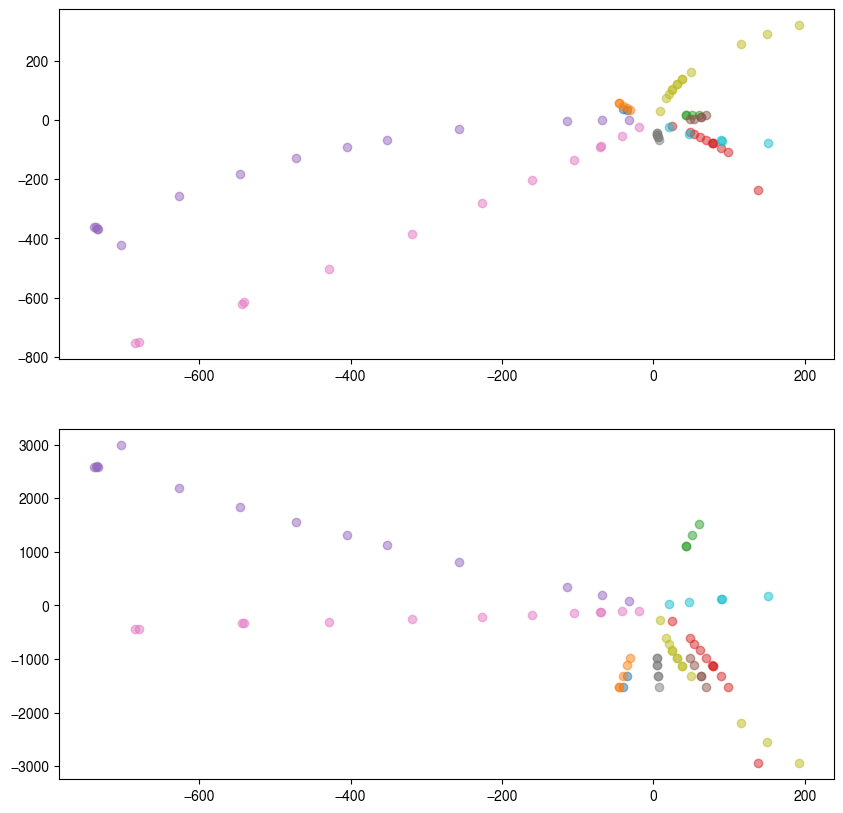

In [21]:
# two subplots, xy and xz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
num_particles_to_sample = 10
long_highpt_particles = particles_df[(particles_df.num_hits > 5) & (particles_df.pt > 1)]
print(f"Number of long highpt particles: {len(long_highpt_particles)}")
random_particle_indices = np.random.choice(len(long_highpt_particles), size=num_particles_to_sample, replace=False)
for i in random_particle_indices:
    particle_id = particles_df.iloc[i].particle_id
    particle_hits = digihits_df[digihits_df.particle_id == particle_id]
    axs[0].scatter(particle_hits.x, particle_hits.y, marker='o', alpha=0.5)
    axs[1].scatter(particle_hits.x, particle_hits.z, marker='o', alpha=0.5)
plt.show()


In [9]:
digihits_df = digihits_df[digihits_df.event_id == 0]

In [10]:
particles_df = particles_df[particles_df.event_id == 0]

In [11]:
tracks_df, track_hits_df = tracks_df[tracks_df.event_id == 0], track_hits_df[track_hits_df.event_id == 0]

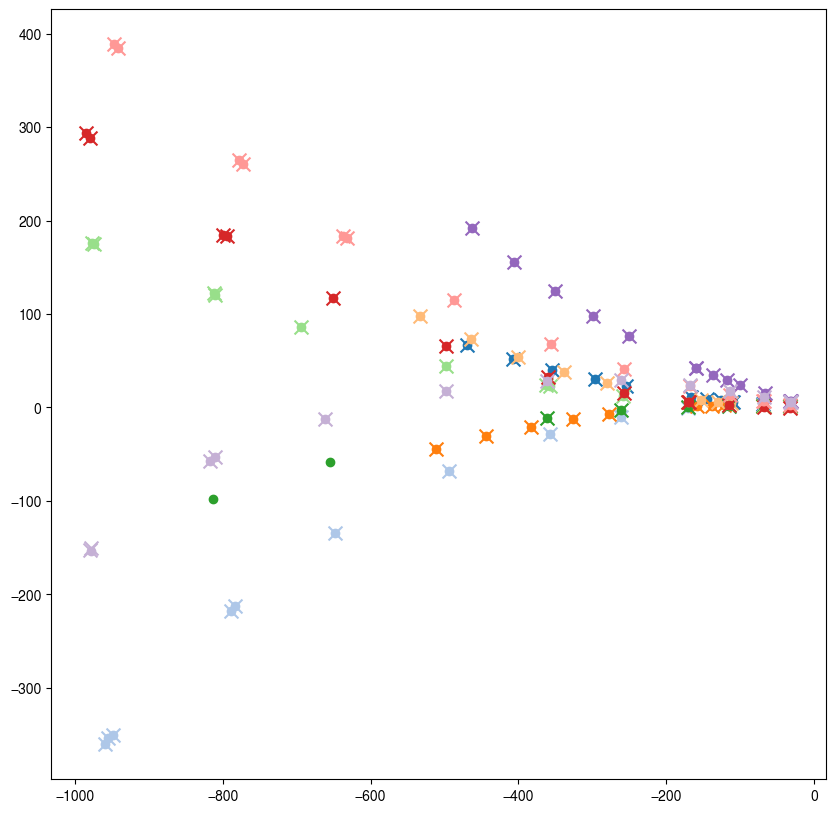

In [12]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

In [13]:
tracks_df

,majority_particle_id,d0,z0,phi,theta,qop,track_id,event_id
0,49874,-0.087343,86.994980,3.111569,2.987114,0.076862,1594,0
1,37773,0.012371,39.290756,3.078784,1.666121,-0.877037,1593,0
2,79866,0.119526,100.076813,3.093044,2.974377,-0.097034,1591,0
3,51368,0.007790,-19.235914,3.137188,2.957829,0.133153,1590,0
4,62181,-0.007198,-24.909479,3.104694,1.028275,-0.358999,1589,0
...,...,...,...,...,...,...,...,...
850,42877,-0.076801,-20.260092,0.651101,3.045254,-0.040476,961,0
851,65174,0.052811,-46.043167,0.770415,3.029800,-0.080225,969,0
852,22511,-0.018417,50.118645,0.917732,2.568353,0.516604,971,0
853,42303,0.031303,3.439590,0.865945,0.848888,-0.488872,972,0


In [14]:
particles_df

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id
0,81,2212,0.938270,2.088655,1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.153240,0.357442,1.825070,1,10.0,0
1,83,-211,0.139570,0.411130,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.349941,-0.123546,-0.108746,1,10.0,0
2,85,-211,0.139570,1.303886,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.515224,1.013931,-0.622196,1,10.0,0
3,88,-211,0.139570,0.367787,-1.0,0.009780,-0.003074,-89.848335,-0.765510,0.120762,0.196509,-0.250176,1,10.0,0
4,89,211,0.139570,1.670073,1.0,0.009780,-0.003074,-89.848335,-0.765510,-1.257038,0.601183,-0.909999,1,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52097,879525,11,0.000511,0.001878,-1.0,-587.023193,36.333473,2192.566162,14.332582,-0.000897,-0.001288,-0.000895,1,349.0,0
52098,879526,11,0.000511,0.000773,-1.0,242.825897,957.259094,2270.417969,10.273644,-0.000568,-0.000115,-0.000024,1,349.0,0
52099,880214,2112,0.939565,0.939693,0.0,599.215210,1192.483765,2467.749512,12.798975,-0.002671,0.014943,-0.003215,1,880193.0,0
52100,880270,11,0.000511,0.001495,-1.0,44.648663,164.044464,238.886871,0.470167,0.001061,0.000171,0.000904,1,350.0,0


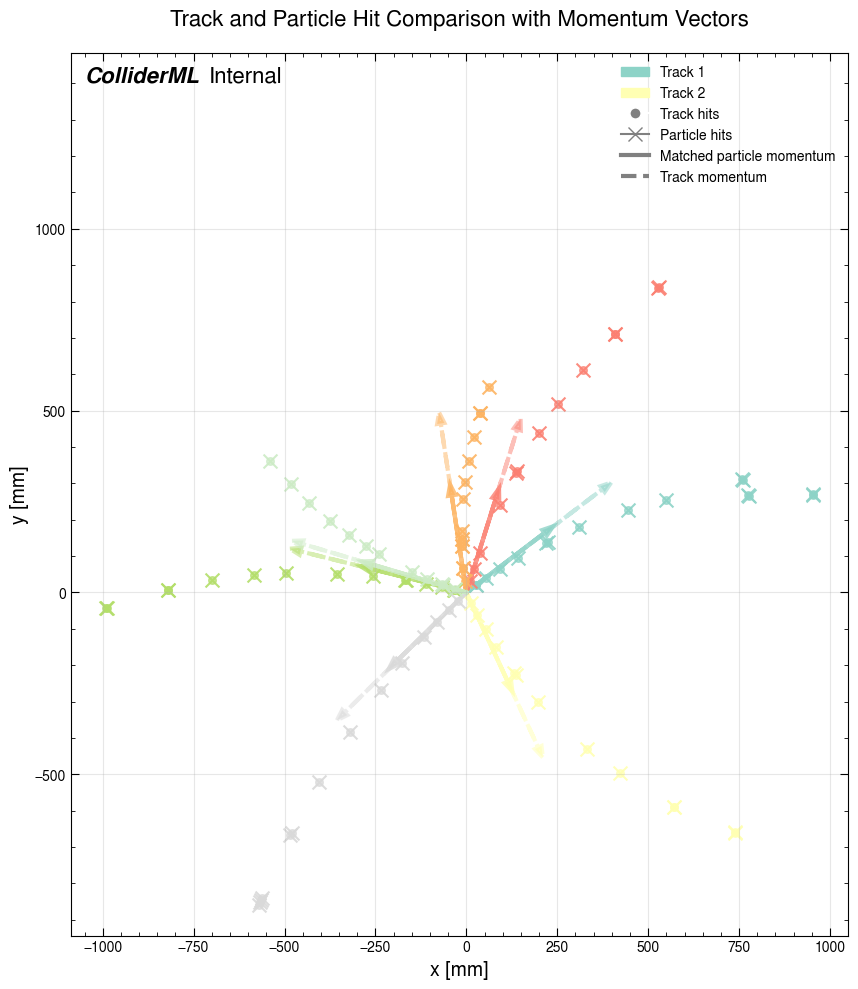

In [42]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


In [45]:
print("Memory usage (per event):")
print(f"Digihits DataFrame: {digihits_df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Tracks DataFrame: {tracks_df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Track Hits DataFrame: {track_hits_df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Particles DataFrame: {particles_df.memory_usage().sum() / 1024**2:.2f} MB")

Memory usage (per event):
Digihits DataFrame: 13.77 MB
Tracks DataFrame: 0.04 MB
Track Hits DataFrame: 0.03 MB
Particles DataFrame: 4.37 MB


In [17]:
tracks_df.iloc[0]

majority_particle_id    49874.000000
d0                         -0.087343
z0                         86.994980
phi                         3.111569
theta                       2.987114
qop                         0.076862
track_id                 1594.000000
event_id                    0.000000
Name: 0, dtype: float64

In [ ]:
particles_df[particles_df['particle_id'] == 37316].iloc[0]

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id
4022,37316,321,0.49368,3.075686,1.0,-0.014769,-0.007004,13.143684,-13.157919,-0.606526,0.931841,2.824876,109,37301.0,0


## Track Conversion

In [117]:
tracks_df.columns

Index(['track_id', 'num_hits', 'num_outliers', 'num_holes', 'num_shared_hits',
       'chi2', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop',
       'time', 'd0_truth', 'z0_truth', 'phi_truth', 'theta_truth',
       'charge_truth', 'p_truth', 'pT_truth', 'time_truth', 'event_id'],
      dtype='object')

In [ ]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v2")  # unified root like scripts

logging.basicConfig(
    level=logging.INFO,  # show DEBUG and above
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,  # override prior configs in this kernel
)

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")

config = {
    "chunk_size": 128,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracks", "tracker_hits"],
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}

In [ ]:
convert_all(config)

In [5]:
edm4hep_path = run_dir / "edm4hep.root"
run_size = 128
batch = EDM4hepEvent(str(edm4hep_path), event_index=0)

2025-09-16 02:27:42,584 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-16 02:27:42,585 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-16 02:27:42,588 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-16 02:27:42,589 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-16 02:27:42,684 - DEBUG - pyedm4hep.utils - Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root...
2025-09-16 02:27:42,694 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-16 02:27:42,695 - DEBUG - fsspec.local - open file: /pscra

In [ ]:
edm_hits_all = batch.get_tracker_hits_df()

In [ ]:
ts_path = run_dir / "tracksummary_ckf.root"
tracksummary_arrays = load_track_summary(str(ts_path))

In [ ]:
ak.to_dataframe(tracksummary_arrays)

In [ ]:
simhits_path = run_dir / "simhits.root"
included_columns = [
    "event_id",
    "tx", "ty", "tz",
    "particle_id"
simhits_df_all = load_root_file(str(simhits_path), included_columns=included_columns)

In [ ]:
measurements_path = run_dir / "measurements.root"
included_columns = [
    "event_nr",
    "true_x",
    "true_y",
    "true_z",
]

measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns)

## Check track hits truth

In [ ]:
base_path = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

In [ ]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

In [ ]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

In [ ]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

In [10]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [12]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [14]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [20]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [21]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [26]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [28]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [101]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [102]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [89]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [95]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


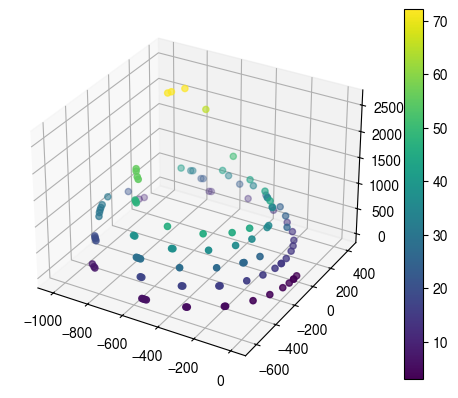

In [99]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)